# Measurement
1. Spectroscopy - goal: resonant freq 
2. separate 0/1, goal: dispersive shift
3. qubit spectroscopy - find qubit mode, power rabi & time rabi (calibrate pi gate) 
4. T1 & Ramsey (T2*) & spin echo(T2) & CPMG (T2)
automation ends
(input of automation: gates, hence need power & time)
5. find the precise qubit freq & pi gate
----- qubit cali ends-----

6. S/ T gates etc or two qubit gate


### Initialization

In [157]:
# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
import laboneq
print(laboneq.__version__)

2.51.0


In [158]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.21 21:06:00.623] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.21 21:06:00.624] INFO    VERSION: laboneq 2.51.0
[2025.08.21 21:06:00.624] INFO    Connecting to data server at 127.0.0.1:8004


[2025.08.21 21:06:00.630] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.21 21:06:00.646] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.21 21:06:00.653] INFO    Configuring the device setup
[2025.08.21 21:06:00.687] INFO    The device setup is configured


## Resonator Spectroscopy

In [159]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
start_freq = -100.0e6 # actual_start_freq = central_freq - start_freq
stop_freq = 300.0e6
center_freq = 7e9
num_points = 1001 # stop - start / (num_points-1)
integration_time = 1e-3
num_averages = 6 # average number = 2^n, n_max = 17

measure_range = -30 # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -15
acquire_amp = 1 #
# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )

In [160]:
# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter
def res_spectroscopy_cw(freq_sweep, exp_settings):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, exp_settings["num_averages"]),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp_spec.sweep(uid="res_freq", parameter=freq_sweep):
            # readout pulse and data acquisition
            with exp_spec.section(uid="spectroscopy"):
                # resonator signal readout
                exp_spec.acquire(
                    signal="acquire",
                    handle="res_spec",
                    length=exp_settings["integration_time"],
                )
            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec.section(uid="relax", length=1e-6):
                exp_spec.reserve(signal="measure")
                exp_spec.reserve(signal="acquire")

    return exp_spec

In [161]:
# function that returns the calibration of the readout line oscillator for the experimental signals


def res_spec_calib(freq_sweep):

    exp_calibration = Calibration()
    exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = freq_sweep, modulation_type=ModulationType.HARDWARE),
    local_oscillator = Oscillator(uid="qa_lo", frequency = center_freq), range = measure_range, amplitude= measure_amp)
    
    exp_calibration["acquire"] = SignalCalibration(range = acquire_range, amplitude= acquire_amp,)

    return exp_calibration


# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# define the experiment with the frequency sweep relevant for qubit 0
freq_sweep = create_readout_freq_sweep("q0", start_freq, stop_freq, num_points)
exp_settings = {"integration_time": integration_time, "num_averages": num_averages}
exp_spec = res_spectroscopy_cw(freq_sweep, exp_settings)

# set signal calibration and signal map for experiment to qubit 0
exp_spec.set_calibration(res_spec_calib(freq_sweep))
exp_spec.set_signal_map(res_spec_map("q0"))

In [162]:
# compile the experiment on the open instrument session
compiled_res_spec = session.compile(exp_spec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet", compiled_res_spec)

[2025.08.21 21:06:00.730] INFO    Starting LabOne Q Compiler run...
[2025.08.21 21:06:00.888] INFO    Schedule completed. [0.152 s]
[2025.08.21 21:06:01.340] INFO    Code generation completed for all AWGs. [0.450 s]
[2025.08.21 21:06:01.340] INFO    Completed compilation step 1 of 1. [0.604 s]
[2025.08.21 21:06:01.340] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.21 21:06:01.340] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.21 21:06:01.340] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.21 21:06:01.340] INFO      device_shfqc     0         27            0           0         0  
[2025.08.21 21:06:01.340] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.21 21:06:01.340] INFO      TOTAL                      27            0                     0  
[2025.08.21 21:06:01.340] INFO     ────────────────────────────────────────────────────

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Resonator_Spectroscopy_Pulse_Sheet_2025-08-21-21-06-01.html

In [163]:
# run the compiled experiemnt and extracted the data
result = session.run(compiled_res_spec)
amp = result.acquired_results["res_spec"].data
freqs = result.acquired_results["res_spec"].axis[0]

[2025.08.21 21:06:02.342] INFO    Starting near-time execution...
[2025.08.21 21:06:02.364] INFO    Estimated RT execution time: 64.13 s.
[2025.08.21 21:07:06.541] WARNING SHFQC/QA:dev12296: Channel 0 Output overrange count: 1
[2025.08.21 21:07:06.574] INFO    Finished near-time execution.


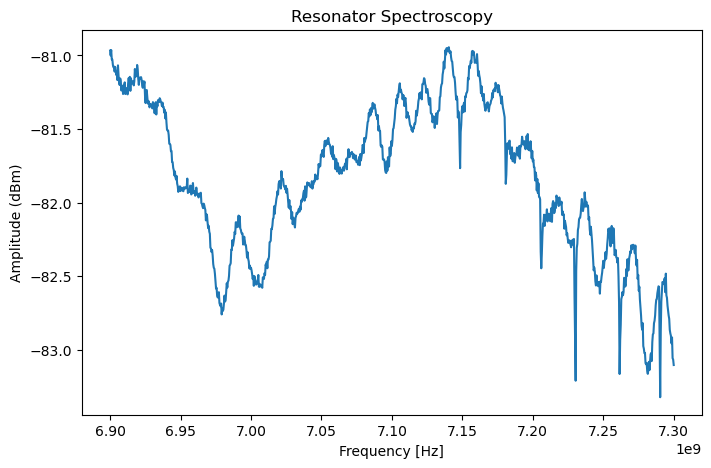

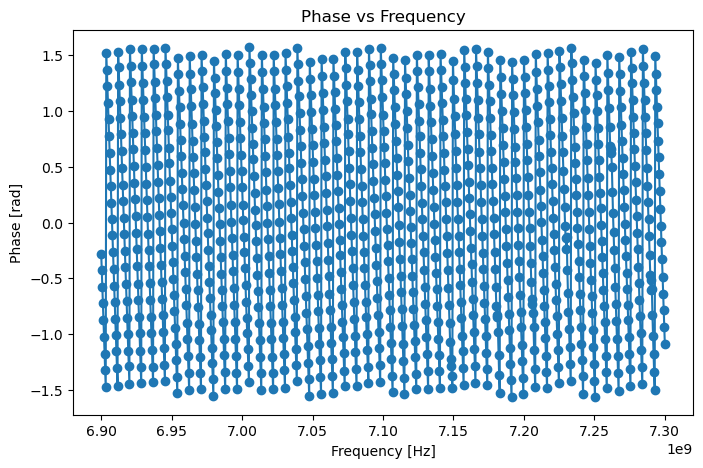

In [164]:
# plot the results
amplitude = np.abs(amp)
power_W = (amplitude**2) / 50  # power in watts
amp_dbm = 10 * np.log10(power_W / 1e-3)  # dBm

freq_list = freqs + center_freq

phase_rad = np.unwrap(np.arctan(amp.imag/amp.real))  
# Plot amplitude vs frequency
plt.figure(figsize=(8,5))
plt.plot(freq_list, amp_dbm, linestyle="-")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude (dBm)")
plt.title("Resonator Spectroscopy")
plt.show()

# --- IQ plane (real vs imaginary) ---
plt.figure(figsize=(8,5))
plt.plot(freq_list, phase_rad, marker="o")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [rad]")
plt.title("Phase vs Frequency")
plt.show()

## Qubit Spectroscopy